# Simple EDA

In [1]:
import pandas as pd

df = pd.read_csv('data/cleaned_data.csv')
print(df.head())

   ad_id          campaign_name     ad_date   location   device  \
0  A1000  data analytics course  2024-11-16  hyderabad  desktop   
1  A1001  data analytics course  2024-11-20  hyderabad   mobile   
2  A1002  data analytics course  2024-11-16  hyderabad  desktop   
3  A1003  data analytics course  2024-11-26  hyderabad   tablet   
4  A1004  data analytics course  2024-11-22  hyderabad  desktop   

                  keyword  impressions  clicks  leads  conversions  \
0    learn data analytics       4498.0   104.0   14.0          7.0   
1   data analytics course       5107.0   173.0   10.0          8.0   
2   data analitics online       4544.0    90.0   26.0          9.0   
3  data anaytics training       3185.0   142.0   17.0          6.0   
4    online data analytic       3361.0   156.0   30.0          8.0   

   conversion_rate  cost_amount  sale_amount  
0            0.067       231.88       1892.0  
1            0.046       216.84       1679.0  
2            0.100       203.66    

In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2597 entries, 0 to 2596
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ad_id            2597 non-null   object 
 1   campaign_name    2597 non-null   object 
 2   ad_date          2597 non-null   object 
 3   location         2597 non-null   object 
 4   device           2597 non-null   object 
 5   keyword          2597 non-null   object 
 6   impressions      2597 non-null   float64
 7   clicks           2597 non-null   float64
 8   leads            2597 non-null   float64
 9   conversions      2597 non-null   float64
 10  conversion_rate  2597 non-null   float64
 11  cost_amount      2597 non-null   float64
 12  sale_amount      2597 non-null   float64
dtypes: float64(7), object(6)
memory usage: 263.9+ KB


## Campaign Performance

In [3]:
# timeseries analysis

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="darkgrid")

df['ad_date'] = pd.to_datetime(df['ad_date'])

df_timeseries = df.groupby('ad_date').agg({'sale_amount': 'sum', 'cost_amount': 'sum'}).reset_index().sort_values('ad_date')
print(df_timeseries.head())
df['roas'] = df['sale_amount'] / df['cost_amount']
print(f'Average ROAS: {df["roas"].mean():.2f}')


     ad_date  sale_amount  cost_amount
0 2024-11-01     114555.2    16694.920
1 2024-11-02     130487.6    18685.998
2 2024-11-03     111913.4    16921.332
3 2024-11-04     126495.8    17530.460
4 2024-11-05     138064.8    19893.502
Average ROAS: 7.03


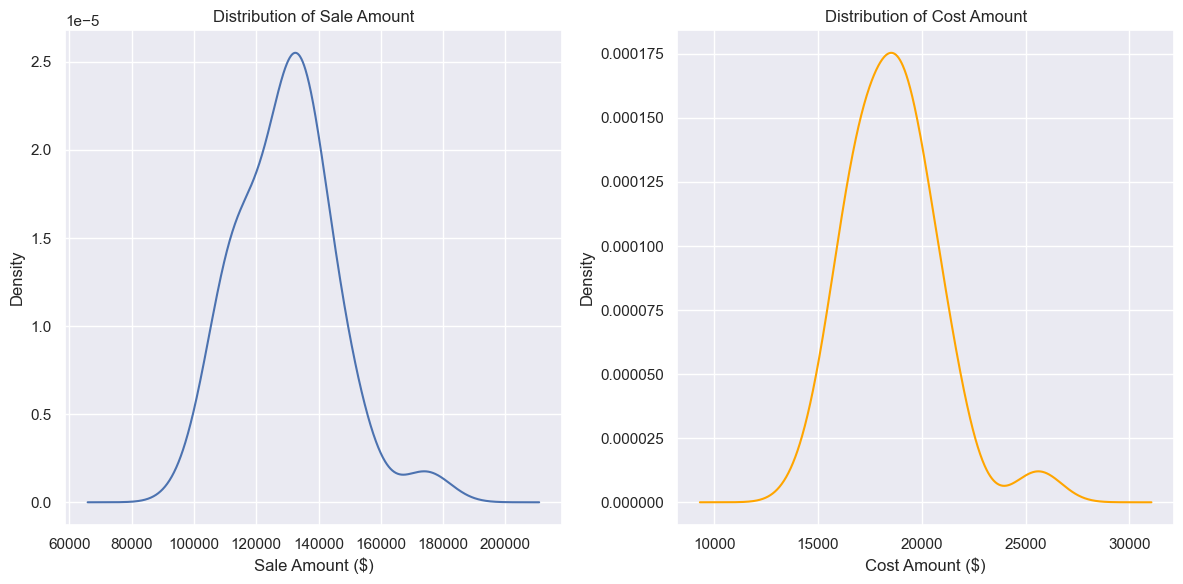

In [4]:
fig, ax = plt.subplots(1,2, figsize=(18, 6))

df_timeseries[['sale_amount']].plot(kind='kde', label='Sale Amount', figsize=(12, 6), ax=ax[0], legend=False)
ax[0].set_xlabel('Sale Amount ($)')
ax[0].set_ylabel('Density')
ax[0].set_title('Distribution of Sale Amount')

df_timeseries[['cost_amount']].plot(kind='kde', label='Cost Amount', figsize=(12, 6), ax=ax[1], color='orange', legend=False)
ax[1].set_xlabel('Cost Amount ($)')
ax[1].set_ylabel('Density')
ax[1].set_title('Distribution of Cost Amount')
plt.tight_layout()
plt.show()

Both distributions look fairly normal.

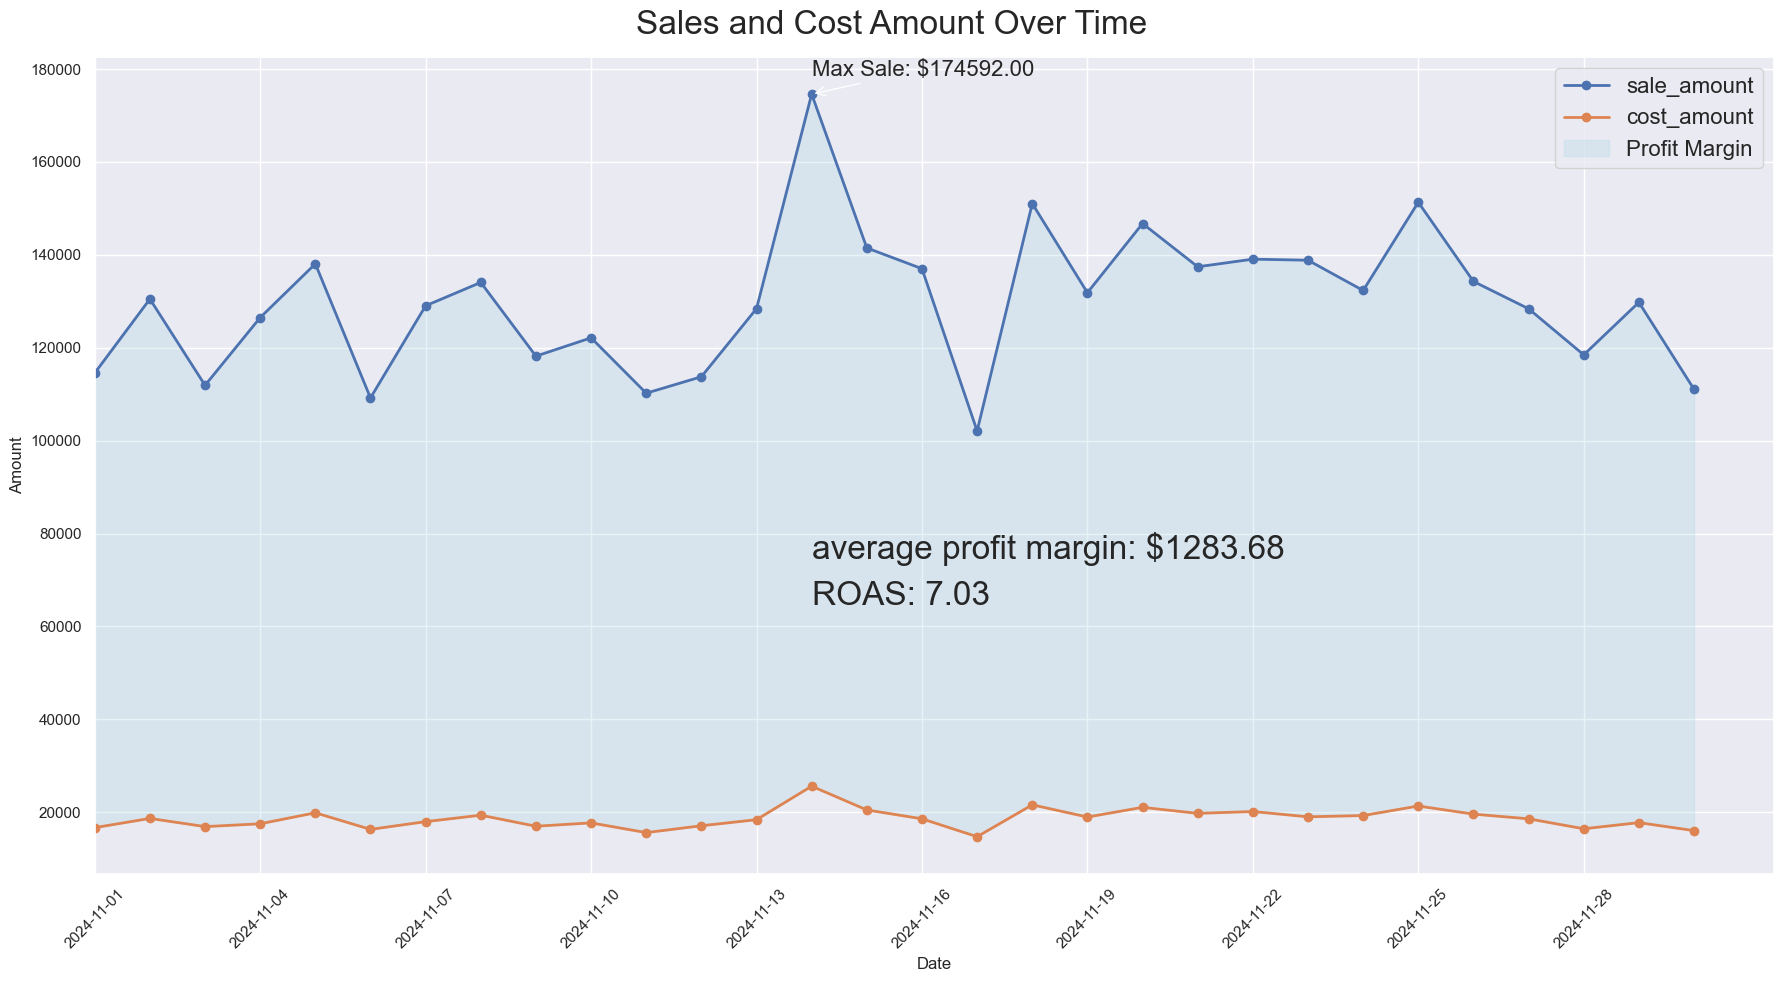

In [5]:
idx_max_sale = df_timeseries['sale_amount'].idxmax()
x_max_sale = df_timeseries.loc[idx_max_sale, 'ad_date']
y_max_sale = df_timeseries.loc[idx_max_sale, 'sale_amount']
xticks_labels = df_timeseries['ad_date'].dt.strftime('%Y-%m-%d').tolist()
x_indices = range(len(df_timeseries))

fig, ax = plt.subplots(figsize=(18, 10))

# Plot lines using numeric indices
ax.plot(x_indices, df_timeseries['sale_amount'].values, linewidth=2, label='sale_amount', marker='o')
ax.plot(x_indices, df_timeseries['cost_amount'].values, linewidth=2, label='cost_amount', marker='o')

# Fill area between lines
ax.fill_between(x_indices, 
                df_timeseries['sale_amount'].values, 
                df_timeseries['cost_amount'].values, 
                alpha=0.3, 
                color='lightblue', 
                label='Profit Margin')

fig.suptitle('Sales and Cost Amount Over Time', fontsize=24)
ax.annotate(f'Max Sale: ${y_max_sale:.2f}', xy=(idx_max_sale, y_max_sale), xytext=(idx_max_sale, y_max_sale + 4000),
            arrowprops=dict(arrowstyle='->', facecolor='black'), fontsize=16)
ax.annotate(f'average profit margin: ${df["sale_amount"].mean() - df["cost_amount"].mean():.2f}', xy=(idx_max_sale, y_max_sale - 100000), xytext=(idx_max_sale, y_max_sale - 100000), fontsize=24)
ax.annotate(f'ROAS: {df["roas"].mean():.2f}', xy=(idx_max_sale, y_max_sale), xytext=(idx_max_sale, y_max_sale - 110000), fontsize=24)
ax.set_xlabel('Date')
ax.set_ylabel('Amount')
step = max(1, len(x_indices) // 10)
ax.set_xticks(x_indices[::step])
ax.set_xticklabels([xticks_labels[i] for i in x_indices[::step]], rotation=45)
ax.set_xlim(
    left=x_indices[0]
)

ax.legend(fontsize=16)
plt.tight_layout()
plt.show()

Sales and Cost almost have identical pattern although sales fluctuates more. There's a spike on November 14, followed by a crash on 16-17 of November, but that also reflects on the cost of ads spent.

             sale_amount  cost_amount
sale_amount     1.000000     0.977125
cost_amount     0.977125     1.000000


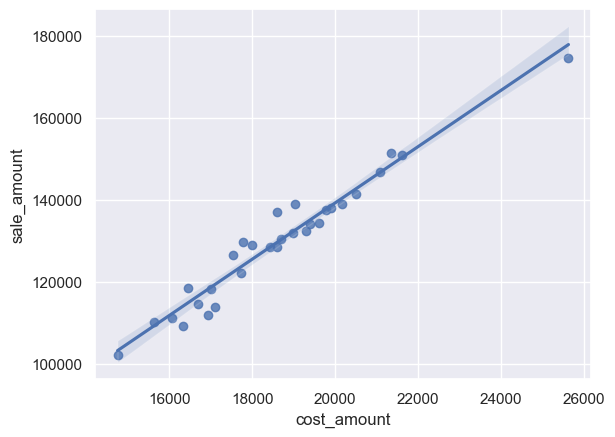

In [6]:
sns.regplot(data=df_timeseries, x='cost_amount', y='sale_amount', label='Sale Amount')

print(df_timeseries[['sale_amount', 'cost_amount']].corr())

Sale and cost has a strong linear correlation as measured by Spearmann Correlation (0.97)

In [49]:
def compute_metrics(df):
    return pd.Series({
        'ctr':               df['clicks'].sum() / df['impressions'].sum() * 100,
        'cvr':               df['conversion_rate'].mean() * 100,
        'cpa':               df['cost_amount'].sum() / df['conversions'].sum(),
        'revenue_per_click': df['sale_amount'].sum() / df['clicks'].sum(),
        'cost_per_click':    df['cost_amount'].sum() / df['clicks'].sum(),
        'roas':              df['roas'].mean()
    })

# overall
overall = df.pipe(compute_metrics)

by_device  = df.groupby('device').apply(compute_metrics, include_groups=False)
by_keyword = df.groupby('keyword').apply(compute_metrics, include_groups=False)

print('Overall Metrics:')
print(overall.T.round(2))
print('\nMetrics by Device:')
print(by_device.round(2))
print('\nMetrics by Keyword:')
print(by_keyword.round(2))

Overall Metrics:
ctr                   3.08
cvr                   5.00
cpa                  32.96
revenue_per_click    10.76
cost_per_click        1.54
roas                  7.03
dtype: float64

Metrics by Device:
          ctr   cvr    cpa  revenue_per_click  cost_per_click  roas
device                                                             
desktop  3.03  5.08  32.70              10.93            1.56  7.06
mobile   3.11  5.03  32.78              10.62            1.54  6.97
tablet   3.11  4.88  33.43              10.72            1.53  7.06

Metrics by Keyword:
                         ctr   cvr    cpa  revenue_per_click  cost_per_click  \
keyword                                                                        
analytics for data      3.03  4.89  33.70              10.72            1.55   
data analitics online   3.09  4.86  33.75              10.74            1.54   
data analytics course   3.11  4.98  32.28              10.67            1.51   
data anaytics training  3

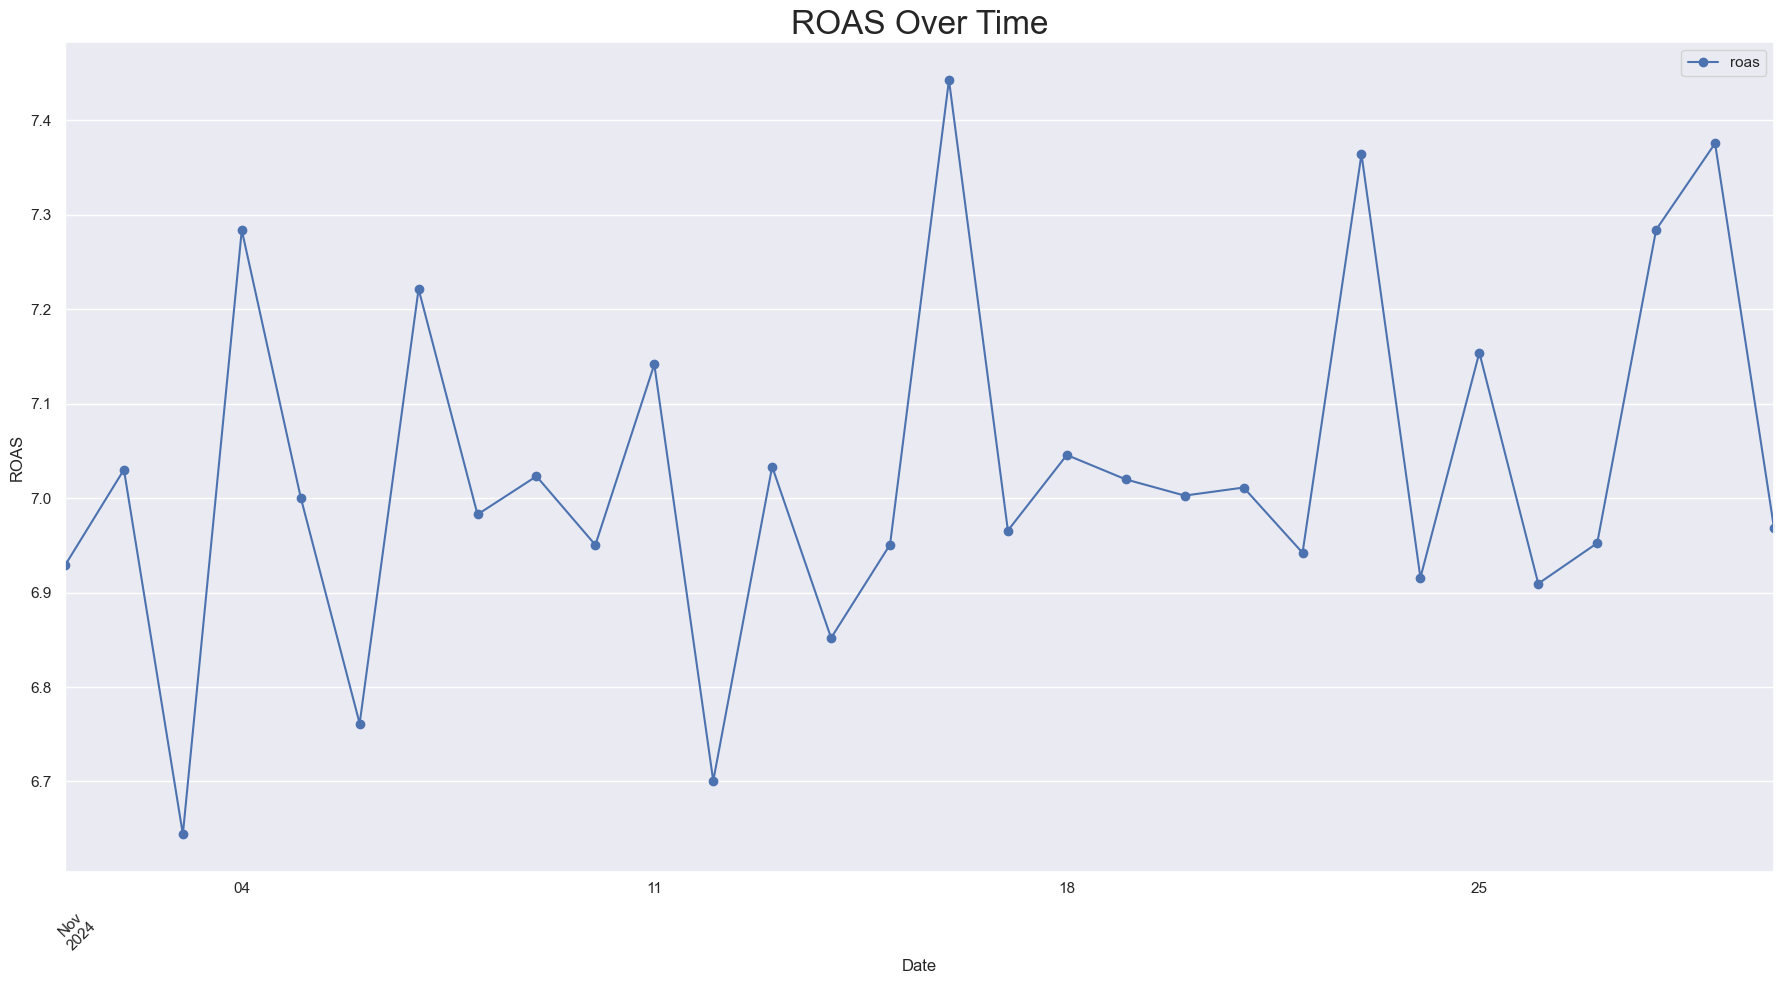

In [8]:
df_roas_timeseries = df[['ad_date','roas']].groupby('ad_date').mean().reset_index().sort_values('ad_date')
df_roas_timeseries.plot(x='ad_date', y='roas', kind='line', figsize=(18, 10), marker='o')
plt.title('ROAS Over Time', fontsize=24)
plt.xlabel('Date')
plt.ylabel('ROAS')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

     ad_date metric     value
0 2024-11-01    ctr  3.429208
1 2024-11-02    ctr  3.025899
2 2024-11-03    ctr  3.087895
3 2024-11-04    ctr  3.399609
4 2024-11-05    ctr  3.363985


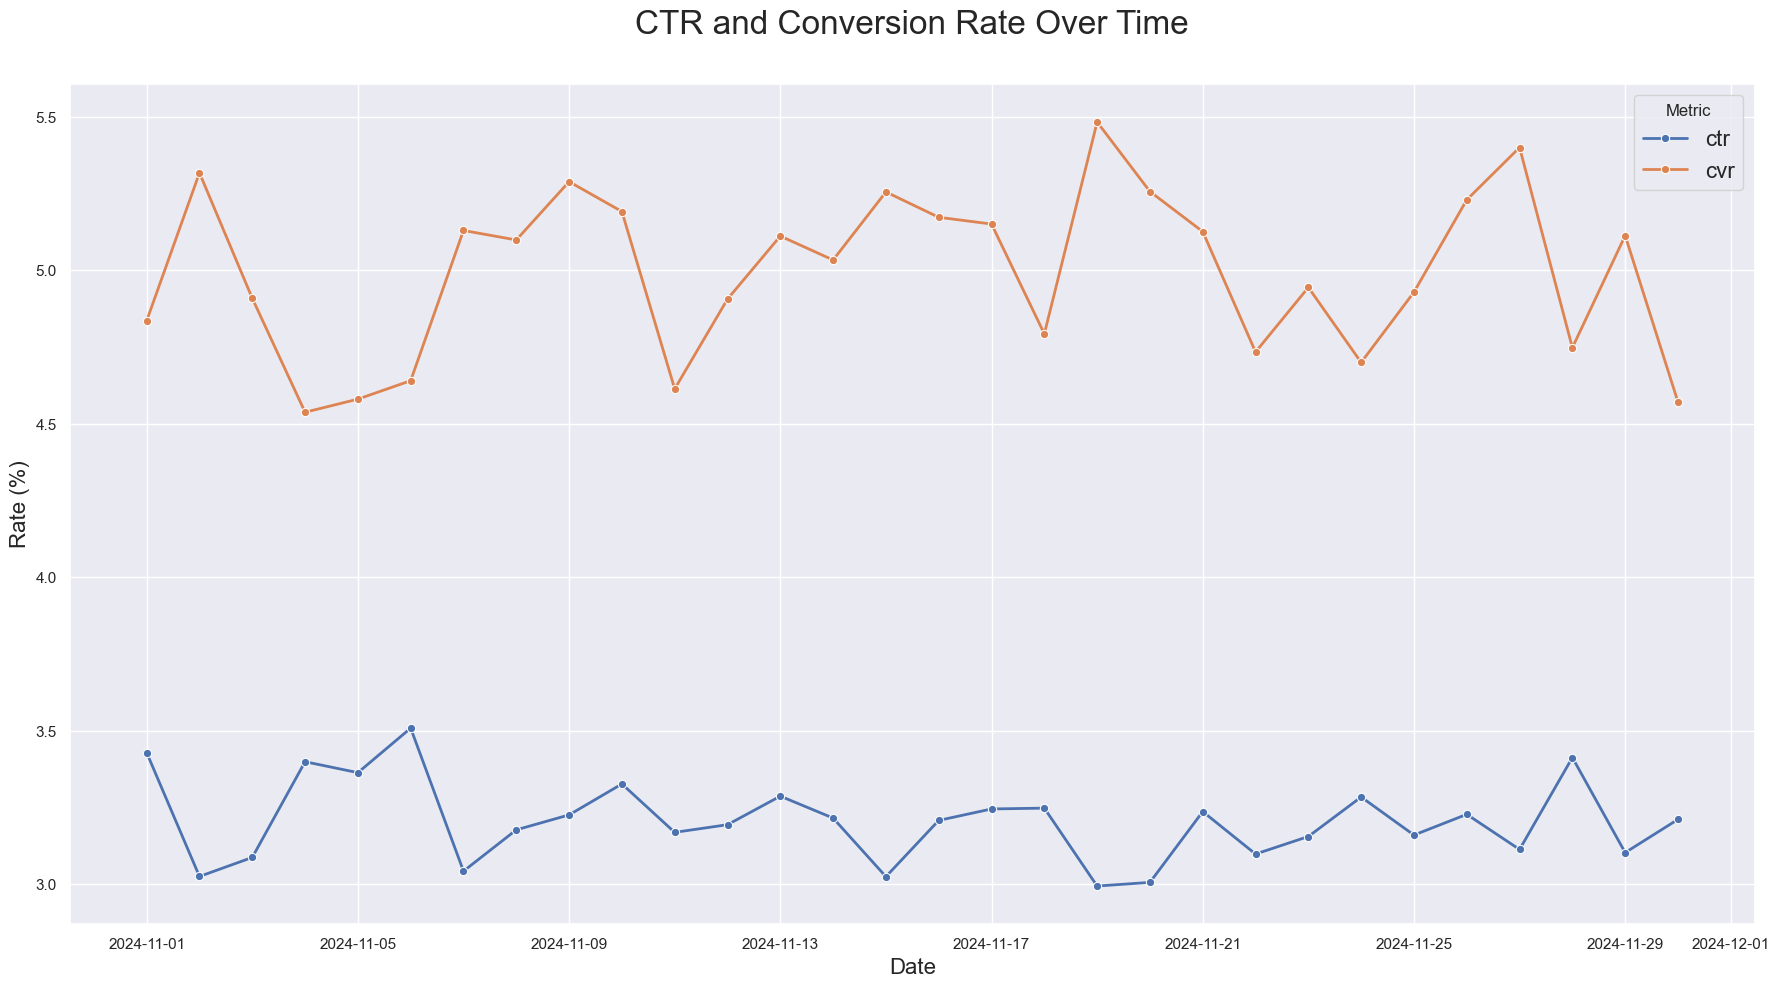

In [9]:
df['ctr'] = df['clicks'] / df['impressions']*100
df['cvr'] = df['conversion_rate']*100

df_ctr_cvr = df.groupby('ad_date')[['ctr', 'cvr']].agg('mean').reset_index()
df_ctr_cvr = df_ctr_cvr.melt(id_vars='ad_date', var_name='metric', value_name='value')
print(df_ctr_cvr.head())

fig, ax = plt.subplots(figsize=(18, 10))
sns.lineplot(data=df_ctr_cvr, x='ad_date', y='value', hue='metric', marker='o', linewidth=2)
ax.set_title('CTR and Conversion Rate Over Time', fontsize=24, y=1.05)
ax.set_xlabel('Date', fontsize=16)
ax.set_ylabel('Rate (%)', fontsize=16)
ax.legend(title='Metric', fontsize=16)
plt.tight_layout()
plt.show()

Priority: improve ad copy and targeting to increase CTR
Not:       fix the landing page (CVR is already healthy)

  day_of_week       ctr       cvr
0      Friday  3.157468  5.010984
1      Monday  3.242666  4.736236
2    Saturday  3.163851  5.066667
3      Sunday  3.238907  4.975786
4    Thursday  3.223072  5.019086
5     Tuesday  3.197570  5.049714
6   Wednesday  3.211382  5.123256


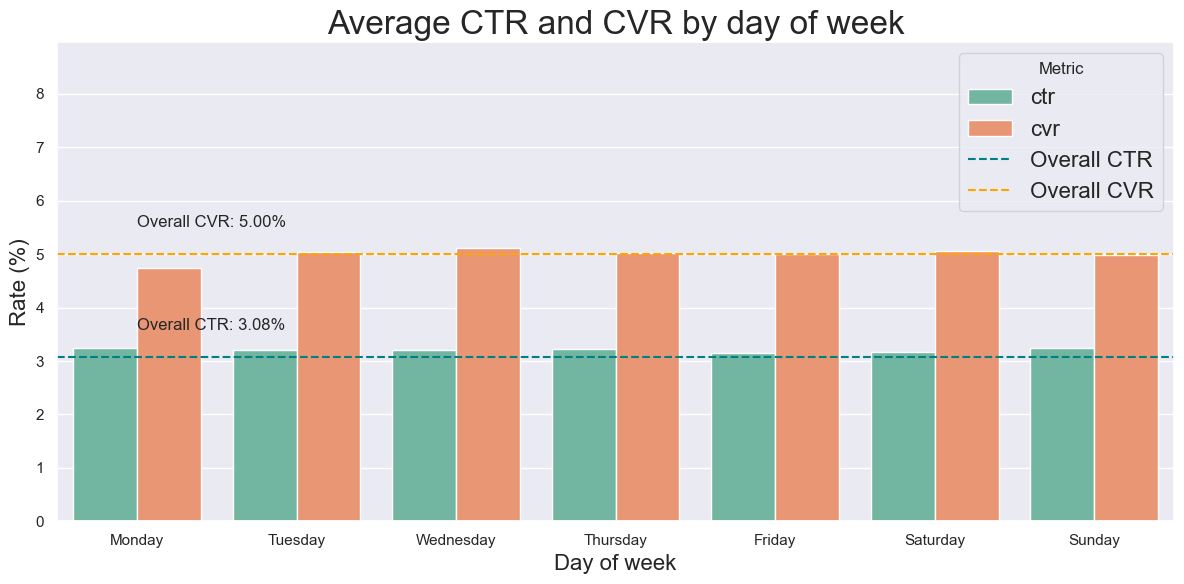

In [48]:
# cvr and ctr per day-of-week
df['day_of_week'] = df['ad_date'].dt.day_name()
df_dow = df.groupby('day_of_week')[['ctr', 'cvr']].mean().reset_index()
print(df_dow)

day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

df_dow_long = df_dow.melt(id_vars='day_of_week', value_vars=['ctr', 'cvr'],
                           var_name='metric', value_name='rate')

fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(data=df_dow_long, x='day_of_week', y='rate', hue='metric',
            order=day_order, ax=ax, palette='Set2', errorbar=('ci', 95))
ax.set_title('Average CTR and CVR by day of week', fontsize=24)
ax.set_xlabel('Day of week', fontsize=16)
ax.set_ylabel('Rate (%)', fontsize=16)
ax.set_ylim(0, df_dow_long['rate'].max() * 1.2)
ax.axhline(overall[ 'ctr'], color='teal', linestyle='--', label=f'Overall CTR')
ax.axhline(overall['cvr'], color='orange', linestyle='--', label=f'Overall CVR')
ax.annotate(f'Overall CTR: {overall["ctr"]:.2f}%', xy=(6.5, overall['ctr']), xytext=(0, overall['ctr'] + 0.5), fontsize=12)
ax.annotate(f'Overall CVR: {overall["cvr"]:.2f}%', xy=(6.5, overall['cvr']), xytext=(0, overall['cvr'] + 0.5), fontsize=12)
ax.legend(title='Metric', fontsize=16)
ax.set_ylim(0, df_dow_long['rate'].max() * 1.75)
plt.tight_layout()
plt.show()

Monday and Sunday's conversion rates fall below the overal conversion rate. Thus, we should put more efforts in marketing on the days other than those two to increase the conversion rate.

Click-through-rate is looking stable

### Sesonal Decomposition

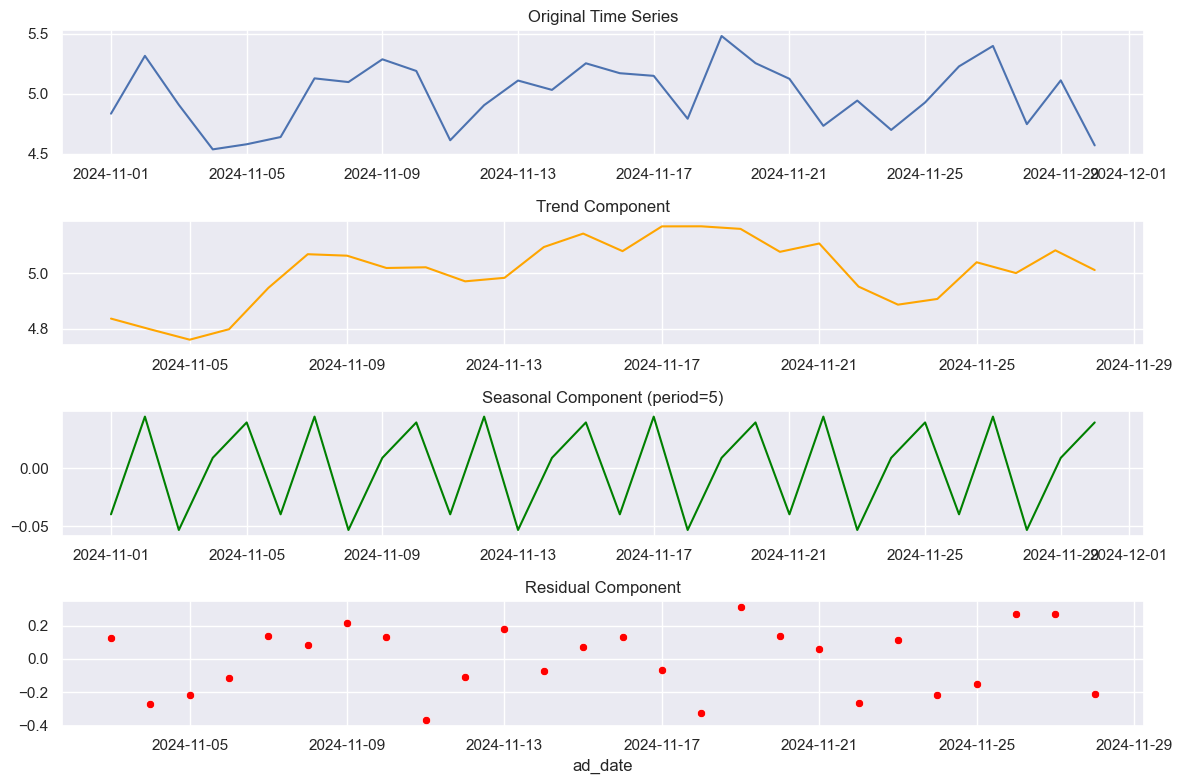

In [23]:
import numpy as np
from statsmodels.tsa.seasonal import seasonal_decompose

decomposition = seasonal_decompose(df_ctr_cvr[df_ctr_cvr['metric'] == 'cvr'][['ad_date','value']].set_index('ad_date'), model='additive', period=5)

# Plot the decomposed components
plt.figure(figsize=(12, 8))

plt.subplot(4, 1, 1)
plt.plot(df_ctr_cvr[df_ctr_cvr['metric'] == 'cvr'][['ad_date','value']].set_index('ad_date'), label='Original Data')
plt.title('Original Time Series')


plt.subplot(4, 1, 2)
plt.plot(decomposition.trend, label='Trend Component', color='orange')
plt.title('Trend Component')


plt.subplot(4, 1, 3)
plt.plot(decomposition.seasonal, label='Seasonal Component', color='green')
plt.title('Seasonal Component (period=5)')


plt.subplot(4, 1, 4)
sns.scatterplot(x=decomposition.resid.index, y=decomposition.resid.values, label='Residual Component', color='red', legend=False)
plt.title('Residual Component')


plt.tight_layout()
plt.show()


In [ ]:
decomposition_7 = seasonal_decompose(df_ctr_cvr[df_ctr_cvr['metric'] == 'cvr'][['ad_date','value']].set_index('ad_date'), model='additive', period=5)

# Plot the decomposed components
plt.figure(figsize=(12, 8))

plt.subplot(4, 1, 1)
plt.plot(df_ctr_cvr[df_ctr_cvr['metric'] == 'cvr'][['ad_date','value']].set_index('ad_date'), label='Original Data')
plt.title('Original Time Series')


plt.subplot(4, 1, 2)
plt.plot(decomposition.trend, label='Trend Component', color='orange')
plt.title('Trend Component')


plt.subplot(4, 1, 3)
plt.plot(decomposition.seasonal, label='Seasonal Component', color='green')
plt.title('Seasonal Component')


plt.subplot(4, 1, 4)
sns.scatterplot(x=decomposition.resid.index, y=decomposition.resid.values, label='Residual Component', color='red', legend=False)
plt.title('Residual Component')


plt.tight_layout()
plt.show()


We couldn't rely on seasonality pattern because 
* the sample is small (30 data points), not enough to detect seasonality
* the seasonality effect is modest (range: -.05 to .05): it wouldn't make any difference if we do action about it (e.g. allocate more budgets in peak days)



In [11]:
high_residuals = decomposition.resid[decomposition.resid.abs() > 0.2]
print("High Residuals:")
print(high_residuals)

High Residuals:
ad_date
2024-11-04   -0.268250
2024-11-05   -0.218713
2024-11-09    0.215187
2024-11-11   -0.368631
2024-11-18   -0.324631
2024-11-19    0.312045
2024-11-22   -0.262871
2024-11-24   -0.216447
2024-11-26    0.268218
2024-11-27    0.271351
2024-11-28   -0.210868
Name: resid, dtype: float64


The dates shown in High Residual worth more investigation, particularly on November 18 to 19, as it was bounced back quite highly. What happened on that day? Is there any particular marketing effort between that day?

## Funnel Analysis

In [12]:
df_funnel = df[['impressions', 'clicks', 'leads', 'conversions']].sum().reset_index()
df_funnel.columns = ['stage', 'count']
print(df_funnel)

         stage       count
0  impressions  11745149.0
1       clicks    361760.0
2        leads     51980.0
3  conversions     16947.0


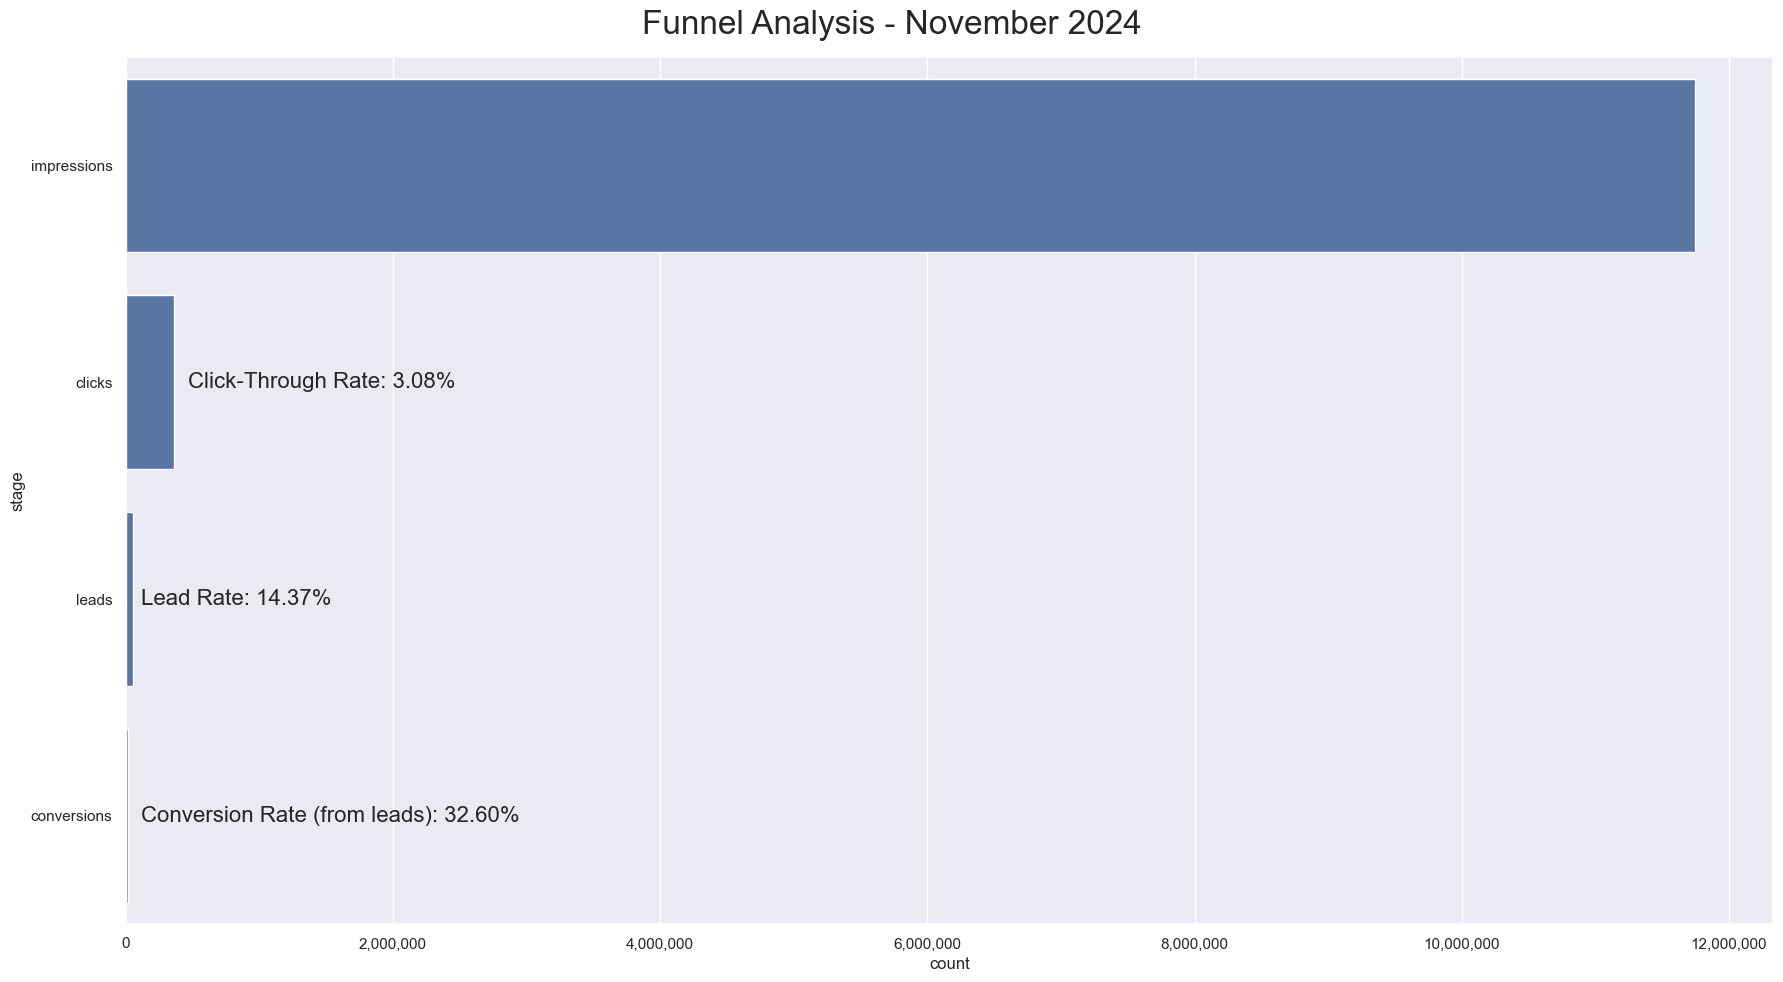

In [13]:
fig, ax = plt.subplots(figsize=(18, 10))
sns.barplot(data=df_funnel, y='stage', x='count', ax=ax)
fig.suptitle('Funnel Analysis - November 2024', fontsize=24)

ax.annotate(
    f'Conversion Rate (from leads): {df["conversions"].sum() / df["leads"].sum() * 100:.2f}%',
    xy=(df_funnel['count'].iloc[3], 3),
    xytext=(df_funnel['count'].max() * 0.01, 3),  
    ha='left',
    va='center',
    fontsize=16
)

ax.annotate(
    f'Lead Rate: {df["leads"].sum() / df["clicks"].sum() * 100:.2f}%',
    xy=(df_funnel['count'].iloc[2], 2),
    xytext=(df_funnel['count'].max() * 0.01, 2),  
    ha='left',
    va='center',
    fontsize=16
)

ax.annotate(
    f'Click-Through Rate: {df["clicks"].sum() / df["impressions"].sum() * 100:.2f}%',
    xy=(df_funnel['count'].iloc[1], 1),
    xytext=(df_funnel['count'].max() * 0.04, 1),  
    ha='left',
    va='center',
    fontsize=16
)

ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.tight_layout()
plt.show()

    device  impressions    clicks    leads  conversions
0  desktop    4020849.0  121889.0  17700.0       5824.0
1   mobile    3973055.0  123386.0  17638.0       5784.0
2   tablet    3751245.0  116485.0  16642.0       5339.0
     device        stage      count
0   desktop       clicks   121889.0
1   desktop  conversions     5824.0
2   desktop  impressions  4020849.0
3   desktop        leads    17700.0
4    mobile       clicks   123386.0
5    mobile  conversions     5784.0
6    mobile  impressions  3973055.0
7    mobile        leads    17638.0
8    tablet       clicks   116485.0
9    tablet  conversions     5339.0
10   tablet  impressions  3751245.0
11   tablet        leads    16642.0


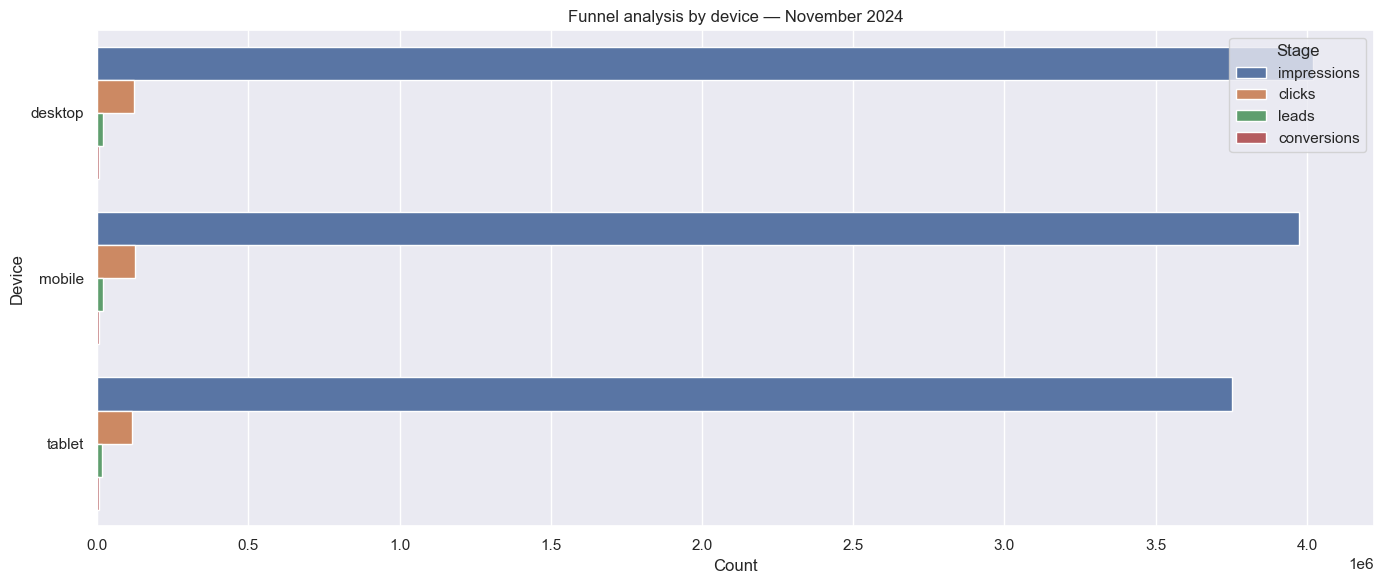

In [17]:
df_funnel_device = df.groupby('device')[['impressions', 'clicks', 'leads', 'conversions']].sum().reset_index()
print(df_funnel_device)

df_funnel_long = df_funnel_device.melt(
    id_vars='device',
    value_vars=['impressions', 'clicks', 'leads', 'conversions'],
    var_name='stage',
    value_name='count'
).groupby(['device', 'stage'], as_index=False)['count'].sum()

print(df_funnel_long)

fig, ax = plt.subplots(figsize=(14, 6))

stage_order = ['impressions', 'clicks', 'leads', 'conversions']

sns.barplot(
    data=df_funnel_long,
    x='count',
    y='device',
    hue='stage',
    hue_order=stage_order,
    ax=ax
)

ax.set_title('Funnel analysis by device — November 2024')
ax.set_xlabel('Count')
ax.set_ylabel('Device')
ax.legend(title='Stage')
plt.tight_layout()
plt.show()

     device        stage     count
0   desktop       clicks  121889.0
1   desktop  conversions    5824.0
3   desktop        leads   17700.0
4    mobile       clicks  123386.0
5    mobile  conversions    5784.0
7    mobile        leads   17638.0
8    tablet       clicks  116485.0
9    tablet  conversions    5339.0
11   tablet        leads   16642.0


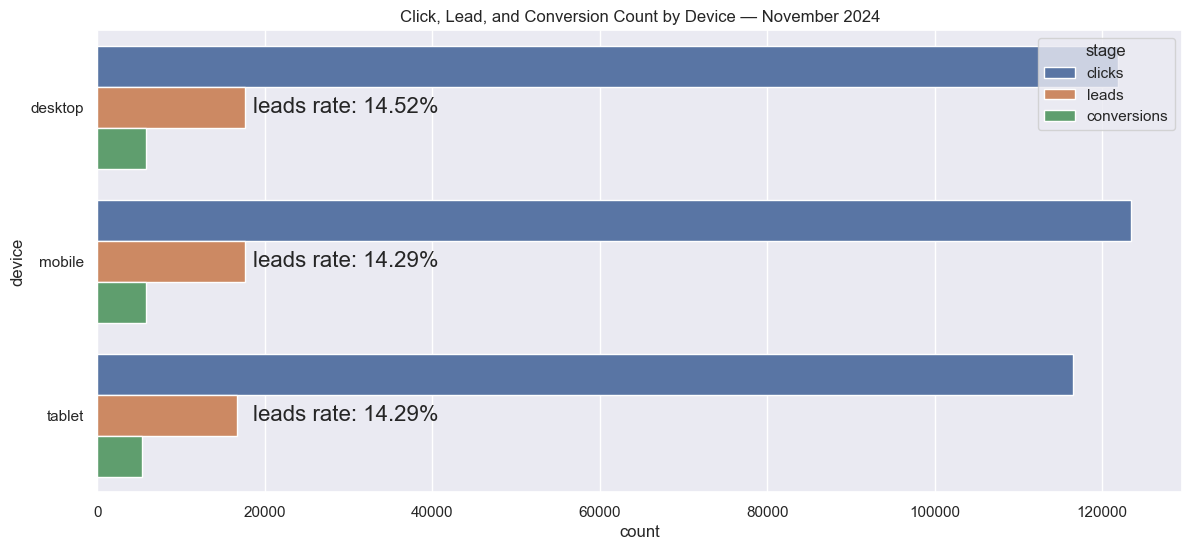

In [18]:
# zooming in on click and conversion by device

df_zoom = df_funnel_long[df_funnel_long['stage'].isin(['clicks', 'leads', 'conversions'])][['device', 'stage', 'count']]
print(df_zoom)

fig, ax = plt.subplots(figsize=(14, 6))
sns.barplot(
    data=df_zoom,
    x='count',
    y='device',
    hue='stage',
    hue_order=['clicks', 'leads', 'conversions'],
    ax=ax
)

# Leads rate for desktop device
ax.annotate(
    f'leads rate: {df[df["device"] == "desktop"]["leads"].sum() / df[df["device"] == "desktop"]["clicks"].sum() * 100:.2f}%',
    xy=(df_zoom[df_zoom['stage'] == 'leads']['count'].max(), 0),
    xytext=(df_zoom[df_zoom['stage'] == 'leads']['count'].max() * 1.05, 0),  
    ha='left',
    va='center',
    fontsize=16
)

# Leads rate for mobile device
ax.annotate(
    f'leads rate: {df[df["device"] == "mobile"]["leads"].sum() / df[df["device"] == "mobile"]["clicks"].sum() * 100:.2f}%',
    xy=(df_zoom[df_zoom['stage'] == 'leads']['count'].max(), 1),
    xytext=(df_zoom[df_zoom['stage'] == 'leads']['count'].max() * 1.05, 1),  
    ha='left',
    va='center',
    fontsize=16
)

# Leads rate for tablet device
ax.annotate(
    f'leads rate: {df[df["device"] == "tablet"]["leads"].sum() / df[df["device"] == "tablet"]["clicks"].sum() * 100:.2f}%',
    xy=(df_zoom[df_zoom['stage'] == 'leads']['count'].max(), 2),
    xytext=(df_zoom[df_zoom['stage'] == 'leads']['count'].max() * 1.05, 2),
    ha='left',
    va='center',
    fontsize=16
)


ax.set_title('Click, Lead, and Conversion Count by Device — November 2024')
plt.show()

In [20]:
print(df['roas'])

0       8.159393
1       7.743036
2       7.974074
3       5.154422
4       5.569168
          ...   
2592    5.857810
2593    7.854036
2594    4.651661
2595    7.077636
2596    5.428299
Name: roas, Length: 2597, dtype: float64


In [22]:
print(df.groupby('keyword').agg(
    {'impressions': 'sum', 
    'clicks': 'sum', 
    'leads': 'sum', 
    'conversions': 'sum', 
    'conversion_rate': 'mean', 
    'roas': 'mean'}).reset_index().sort_values('conversion_rate', ascending=False).head(10))

                  keyword  impressions   clicks   leads  conversions  \
4    learn data analytics    1973935.0  60594.0  8923.0       2900.0   
3  data anaytics training    1886696.0  57798.0  8111.0       2735.0   
5    online data analytic    2014618.0  62952.0  8877.0       2989.0   
2   data analytics course    2002914.0  62261.0  8930.0       2905.0   
0      analytics for data    1969461.0  59595.0  8671.0       2746.0   
1   data analitics online    1897525.0  58560.0  8468.0       2672.0   

   conversion_rate      roas  
4         0.051378  7.062098  
3         0.050877  7.083621  
5         0.050383  6.884543  
2         0.049791  7.152467  
0         0.048904  6.961915  
1         0.048554  7.034999  


"Learn Data Analytics" has the highest conversion rate although not in a high margin to the others.

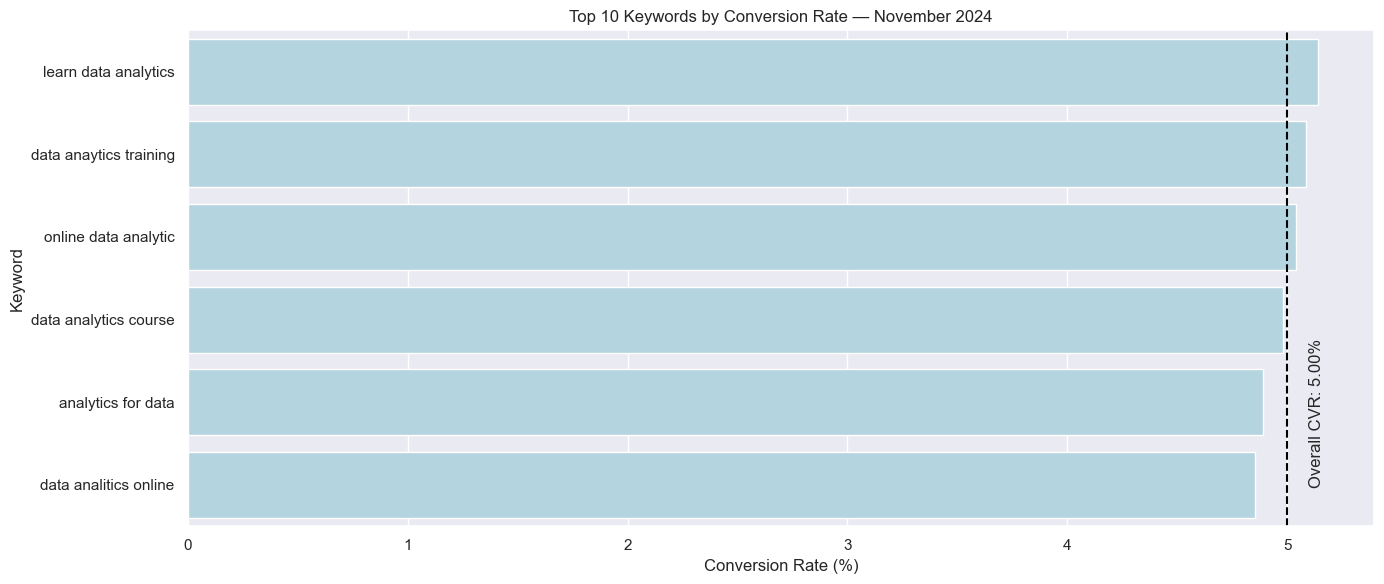

In [61]:
fig, ax = plt.subplots(figsize=(14, 6))
sns.barplot(
    data=df.groupby('keyword')['cvr'].mean().reset_index().sort_values('cvr', ascending=False).head(10),
    x='cvr',
    y='keyword',
    color='lightblue',
    ax=ax
)
ax.set_title('Top 10 Keywords by Conversion Rate — November 2024')
ax.set_xlabel('Conversion Rate (%)')
ax.set_ylabel('Keyword')
ax.axvline(overall['cvr'], color='black', linestyle='--', label=f'Overall CVR')
ax.annotate(f'Overall CVR: {overall["cvr"]:.2f}%', xy=(overall['cvr'], 5), xytext=(overall['cvr'] + 0.1, 5), fontsize=12, rotation=90)
plt.tight_layout()